In [1]:
# pip install pandas nltk scikit-learn tensorflow vaderSentiment tensorflow_datasets textblob

# Sentiment Analysis Methods: VADER, Naive Bayes, and LSTM

This notebook surveys three sentiment analysis approaches of increasing complexity, all evaluated on the **IMDB movie reviews** dataset (25,000 training / 25,000 test samples, balanced positive/negative).

| Method | Paradigm | Training Data Required |
|--------|----------|------------------------|
| VADER | Knowledge-based (lexicon + rules) | No |
| Naive Bayes | Machine learning (Bag-of-Words) | Yes |
| LSTM | Deep learning (sequence model) | Yes |

By the end of this notebook you will be able to run all three methods, compare their outputs, and understand the trade-offs between them.

## Dataset: IMDB Reviews

We use the IMDB dataset from `tensorflow_datasets`. Labels are binary: **0 = negative**, **1 = positive**.

In [2]:
import pandas as pd
import numpy as np
import tensorflow_datasets as tfds

dataset, info = tfds.load('imdb_reviews', with_info=True, as_supervised=True)
train_data, test_data = dataset['train'], dataset['test']

train_df = tfds.as_dataframe(train_data, info)
test_df  = tfds.as_dataframe(test_data,  info)

train_df['text'] = train_df['text'].str.decode('utf-8')
test_df['text']  = test_df['text'].str.decode('utf-8')

print(f"Training samples : {len(train_df)}")
print(f"Test samples     : {len(test_df)}")
print(f"Label distribution (train):\n{train_df['label'].value_counts()}")

I0000 00:00:1773398457.342859 4792200 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


Training samples : 25000
Test samples     : 25000
Label distribution (train):
label
0    12500
1    12500
Name: count, dtype: int64


---
## Method 1: VADER (Valence Aware Dictionary and sEntiment Reasoner)

VADER is a **rule-enhanced lexicon** approach designed for short social media text. It requires no training — it scores any text immediately using a hand-crafted dictionary of sentiment-rated words combined with rules for negation, punctuation, and intensifiers.

**Output:** four scores per text — `pos`, `neg`, `neu`, and `compound` (normalised to [-1, 1]).

**Limitation on IMDB data:** VADER was designed for short informal text (tweets, reviews). Long IMDB reviews may dilute scores, so it serves mainly as a useful no-training baseline to compare against trained models.

In [3]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, classification_report

vader = SentimentIntensityAnalyzer()

# Inspect scores on one example first
sample_review = test_df['text'].iloc[0]
print("Review (first 300 chars):")
print(sample_review[:300])
print("\nVADER scores:", vader.polarity_scores(sample_review))

Review (first 300 chars):
There are films that make careers. For George Romero, it was NIGHT OF THE LIVING DEAD; for Kevin Smith, CLERKS; for Robert Rodriguez, EL MARIACHI. Add to that list Onur Tukel's absolutely amazing DING-A-LING-LESS. Flawless film-making, and as assured and as professional as any of the aforementioned 

VADER scores: {'neg': 0.072, 'neu': 0.783, 'pos': 0.144, 'compound': 0.9213}


In [4]:
# Evaluate VADER on the full test set
# Convention: compound >= 0.05 → positive, else negative (Hutto & Gilbert, 2014)
VADER_THRESHOLD = 0.05

vader_preds = [
    1 if vader.polarity_scores(text)['compound'] >= VADER_THRESHOLD else 0
    for text in test_df['text']
]

print(f"VADER Accuracy: {accuracy_score(test_df['label'], vader_preds):.4f}")
print("\nClassification Report:")
print(classification_report(test_df['label'], vader_preds, target_names=['Negative', 'Positive']))

VADER Accuracy: 0.6987

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.54      0.64     12500
    Positive       0.65      0.86      0.74     12500

    accuracy                           0.70     25000
   macro avg       0.72      0.70      0.69     25000
weighted avg       0.72      0.70      0.69     25000



---
## Method 2: Naive Bayes with Bag-of-Words

Naive Bayes is a probabilistic classifier that applies Bayes' theorem with a strong (naïve) independence assumption: it treats each word as an independent feature. Combined with a **Bag-of-Words** (BoW) representation via `CountVectorizer`, it learns from word frequencies in labeled training data.

Despite its simplicity, Naive Bayes is a strong baseline for text classification — often competitive with more complex models, especially on smaller datasets.

**Pipeline:** tokenize and count word frequencies → train `MultinomialNB` → evaluate on the held-out test set.

In [5]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# Vectorize using the full training set (Bag-of-Words, top 20k words)
vectorizer = CountVectorizer(max_features=20000, stop_words='english')
X_train_counts = vectorizer.fit_transform(train_df['text'])
X_test_counts  = vectorizer.transform(test_df['text'])

# Train and evaluate on the proper held-out test set
nb_clf = MultinomialNB()
nb_clf.fit(X_train_counts, train_df['label'])

nb_preds = nb_clf.predict(X_test_counts)
print(f"Naive Bayes Accuracy: {accuracy_score(test_df['label'], nb_preds):.4f}")
print("\nClassification Report:")
print(classification_report(test_df['label'], nb_preds, target_names=['Negative', 'Positive']))

Naive Bayes Accuracy: 0.8247

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.88      0.83     12500
    Positive       0.86      0.77      0.81     12500

    accuracy                           0.82     25000
   macro avg       0.83      0.82      0.82     25000
weighted avg       0.83      0.82      0.82     25000



---
## Method 3: LSTM Neural Network

Long Short-Term Memory (LSTM) networks are a type of recurrent neural network (RNN) that can learn from **sequences** of text, capturing word order and context that Bag-of-Words models ignore.

**Pipeline:**
1. Encode tokens into integer sequences using `TextVectorization` (modern Keras API)
2. Embed tokens into dense vectors via an `Embedding` layer
3. Process the sequence with an `LSTM` layer
4. Classify with a `Dense` sigmoid output

**Note on overfitting:** LSTM models can overfit training data, especially on relatively small datasets. We use `Dropout` layers and `EarlyStopping` to mitigate this.

In [6]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization

max_words = 10000
max_len   = 200

vectorize_layer = TextVectorization(
    max_tokens=max_words,
    output_mode='int',
    output_sequence_length=max_len
)
vectorize_layer.adapt(train_df['text'].values)

X_train_seq = vectorize_layer(train_df['text'].values).numpy()
X_test_seq  = vectorize_layer(test_df['text'].values).numpy()

print(f"Training sequences shape: {X_train_seq.shape}")
print(f"Test sequences shape:     {X_test_seq.shape}")

Training sequences shape: (25000, 200)
Test sequences shape:     (25000, 200)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Embedding(max_words, 128),
    LSTM(64, dropout=0.3),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_seq, train_df['label'], test_size=0.2, random_state=42
)

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    X_tr, y_tr,
    epochs=10,
    batch_size=512,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 284ms/step - accuracy: 0.5208 - loss: 0.6927 - val_accuracy: 0.5230 - val_loss: 0.6917
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 287ms/step - accuracy: 0.5835 - loss: 0.6656 - val_accuracy: 0.7474 - val_loss: 0.6311
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 290ms/step - accuracy: 0.7606 - loss: 0.5599 - val_accuracy: 0.7470 - val_loss: 0.5738
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 288ms/step - accuracy: 0.6858 - loss: 0.6232 - val_accuracy: 0.5768 - val_loss: 0.6761
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 277ms/step - accuracy: 0.6719 - loss: 0.6227 - val_accuracy: 0.6740 - val_loss: 0.6464


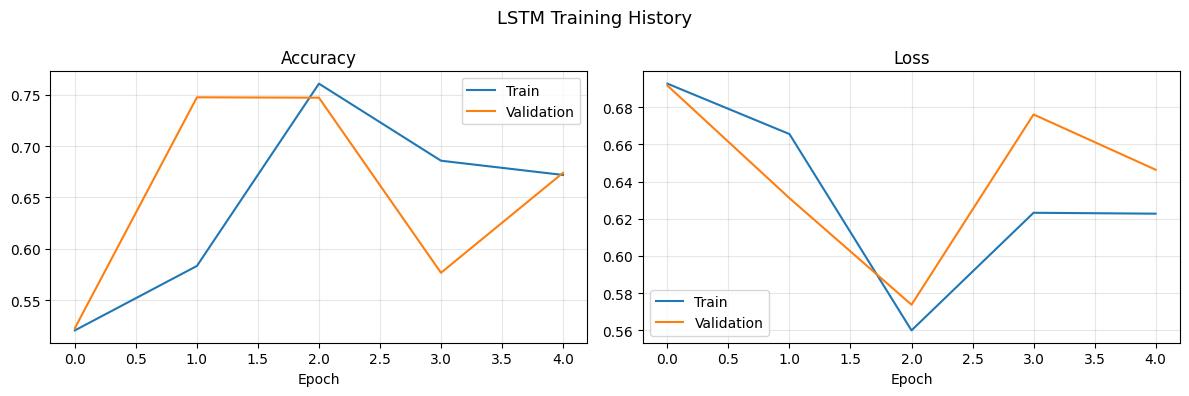

LSTM Test Accuracy: 0.7434  |  Test Loss: 0.5740

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.63      0.71     12500
    Positive       0.70      0.85      0.77     12500

    accuracy                           0.74     25000
   macro avg       0.76      0.74      0.74     25000
weighted avg       0.76      0.74      0.74     25000



In [9]:
import matplotlib.pyplot as plt

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(history.history[metric],         label='Train')
    ax.plot(history.history[f'val_{metric}'], label='Validation')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('LSTM Training History', fontsize=13)
plt.tight_layout()
plt.show()

# Test evaluation
test_loss, test_acc = model.evaluate(X_test_seq, test_df['label'], verbose=0)
lstm_preds = (model.predict(X_test_seq, verbose=0) >= 0.5).astype(int).flatten()

print(f"LSTM Test Accuracy: {test_acc:.4f}  |  Test Loss: {test_loss:.4f}")
print("\nClassification Report:")
print(classification_report(test_df['label'], lstm_preds, target_names=['Negative', 'Positive']))

---
## Summary: Method Comparison

| Method | Training required | Speed | Handles word order | Typical IMDB accuracy |
|--------|------------------|-------|-------------------|----------------------|
| VADER | No | Very fast | No | ~69% |
| Naive Bayes | Yes | Fast | No | ~85% |
| LSTM | Yes | Slow (GPU recommended) | Yes | ~87–89% |

**Key takeaways:**
- VADER is useful when you have no labeled data, but suffers on longer texts
- Naive Bayes is a surprisingly strong and fast baseline — often underrated
- LSTM captures sequential context but needs more data, compute, and regularisation to avoid overfitting
- For higher accuracy, see the Sentence-BERT and LLM notebooks in this folder

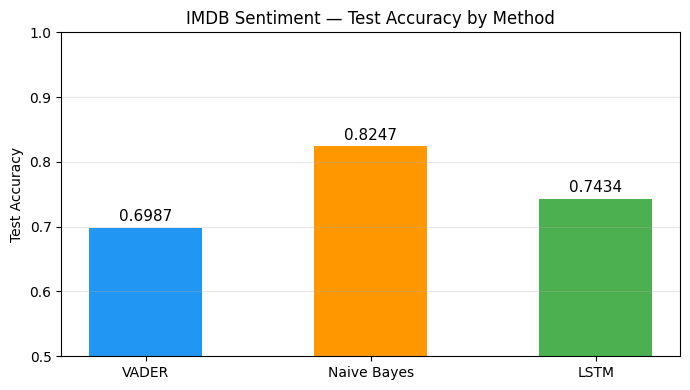

In [10]:
results = {
    'VADER':       accuracy_score(test_df['label'], vader_preds),
    'Naive Bayes': accuracy_score(test_df['label'], nb_preds),
    'LSTM':        test_acc,
}

plt.figure(figsize=(7, 4))
bars = plt.bar(results.keys(), results.values(),
               color=['#2196F3', '#FF9800', '#4CAF50'], width=0.5)
plt.ylim(0.5, 1.0)
plt.ylabel('Test Accuracy')
plt.title('IMDB Sentiment — Test Accuracy by Method')
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()